# Alpha-Enhancement: How [α/Fe] Changes the SED

Stars don't all have the same abundance pattern. Old stellar populations
formed before Type Ia supernovae enriched the ISM with iron, so they have
elevated [α/Fe] ratios (+0.3 to +0.5 dex). This notebook demonstrates:

1. **What [α/Fe] does to an SED** — using 4D alpha-enhanced SSP grids
2. **Solar [α/Fe] = 0 reproduces standard SSPs** — backward compatibility
3. **Time-evolving [α/Fe]** — old stars α-enhanced, young stars solar
4. **[Fe/H] vs [M/H] conventions** — the Salaris relation
5. **When alpha-enhancement matters** — photometry vs spectroscopy

This notebook uses **synthetic 4D SSP grids** for demonstration.
For real science, load sMILES, BPASS v2.3, or α-MC templates.

In [1]:
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

import sys
import os

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
if os.path.exists("data"):
    pass
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

from _plot_style import COLORS, setup_style

setup_style()

FIGDIR = os.path.join("reference", "figures")
os.makedirs(FIGDIR, exist_ok=True)

## 1. Build a Synthetic 4D Alpha-Enhanced SSP Grid

In practice you'd load real templates (sMILES, BPASS v2.3, α-MC).
Here we build a synthetic grid that captures the key physics:
- Higher [α/Fe] → stronger Mg features (~5170 Å), weaker Fe lines (~5270 Å)
- Higher [α/Fe] at fixed [Fe/H] → slightly redder continuum (more total Z)
- Effect is strongest for old populations, weak for young hot stars

In [2]:
from tengri.models.sps.dsps_wrapper import SSPData

# Grid dimensions
n_met, n_alpha, n_age, n_wave = 5, 5, 40, 500
feh_grid = jnp.array([-2.0, -1.5, -1.0, -0.5, 0.0])
alpha_grid = jnp.array([-0.2, 0.0, 0.2, 0.4, 0.6])
lg_age_gyr = jnp.linspace(-1.5, 1.14, n_age)  # 0.03 to 13.8 Gyr
wave = jnp.linspace(3500.0, 9500.0, n_wave)

# Build synthetic SSP flux
# Start from a simple power-law continuum that varies with Z and age
key = jax.random.PRNGKey(42)
base_flux = jnp.abs(jax.random.normal(key, (n_met, n_alpha, n_age, n_wave))) * 1e-6 + 1e-7

# Add physical trends
# Metallicity: redder at higher Z
z_reddening = jnp.exp(-0.0003 * (wave - 5500.0))  # redder = more flux at long λ
met_scale = 10.0 ** (0.3 * feh_grid)  # brighter at higher Z
base_flux = base_flux * met_scale[:, None, None, None] * (1.0 + 0.1 * z_reddening[None, None, None, :])

# Age: bluer (more UV) when young
age_gyr = 10.0 ** lg_age_gyr
uv_boost = jnp.exp(-0.001 * (wave - 3500.0))
age_weight = jnp.clip(1.0 / (age_gyr + 0.01), 0.1, 10.0)
base_flux = base_flux * (1.0 + 0.5 * age_weight[None, None, :, None] * uv_boost[None, None, None, :])

# Alpha enhancement effects:
# 1. Mg b feature at ~5170 Å (stronger at high [α/Fe])
mg_feature = jnp.exp(-0.5 * ((wave - 5170.0) / 15.0) ** 2)
# 2. Fe 5270 line (weaker at high [α/Fe] because less Fe at fixed total Z)
fe_feature = jnp.exp(-0.5 * ((wave - 5270.0) / 12.0) ** 2)
# 3. Ca H&K at 3933, 3968 Å (stronger at high [α/Fe])
ca_hk = jnp.exp(-0.5 * ((wave - 3950.0) / 20.0) ** 2)

for i_alpha, afe in enumerate(alpha_grid):
    # Absorption features (subtract from continuum)
    alpha_effect = (
        0.15 * float(afe) * mg_feature   # Mg b deeper at high α
        - 0.10 * float(afe) * fe_feature  # Fe weaker at high α (negative = less absorption)
        + 0.08 * float(afe) * ca_hk        # Ca stronger at high α
    )
    # Scale by age: effect stronger for old populations
    old_weight = jnp.clip(age_gyr / 5.0, 0.0, 1.0)
    base_flux = base_flux.at[:, i_alpha, :, :].add(
        -base_flux[:, i_alpha, :, :] * alpha_effect[None, None, :] * old_weight[None, :, None]
    )

# Ensure positive
base_flux = jnp.maximum(base_flux, 1e-10)

ssp_4d = SSPData(
    ssp_wave=wave,
    ssp_flux=base_flux,
    ssp_lg_age_gyr=lg_age_gyr,
    ssp_lgmet=feh_grid,
    ssp_alpha_fe=alpha_grid,
)

print(f"4D SSP grid: {base_flux.shape}")
print(f"[Fe/H] grid: {feh_grid}")
print(f"[α/Fe] grid: {alpha_grid}")
print(f"Ages: {float(10**lg_age_gyr[0]):.3f} to {float(10**lg_age_gyr[-1]):.1f} Gyr")

W0322 22:43:46.888030 17226739 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


4D SSP grid: (5, 5, 40, 500)
[Fe/H] grid: [-2.  -1.5 -1.  -0.5  0. ]
[α/Fe] grid: [-0.2  0.   0.2  0.4  0.6]
Ages: 0.032 to 13.8 Gyr


## 2. How [α/Fe] Changes an SSP Spectrum

At fixed [Fe/H] and age, varying [α/Fe] produces distinct spectral
signatures — primarily in absorption line strengths, not the continuum.

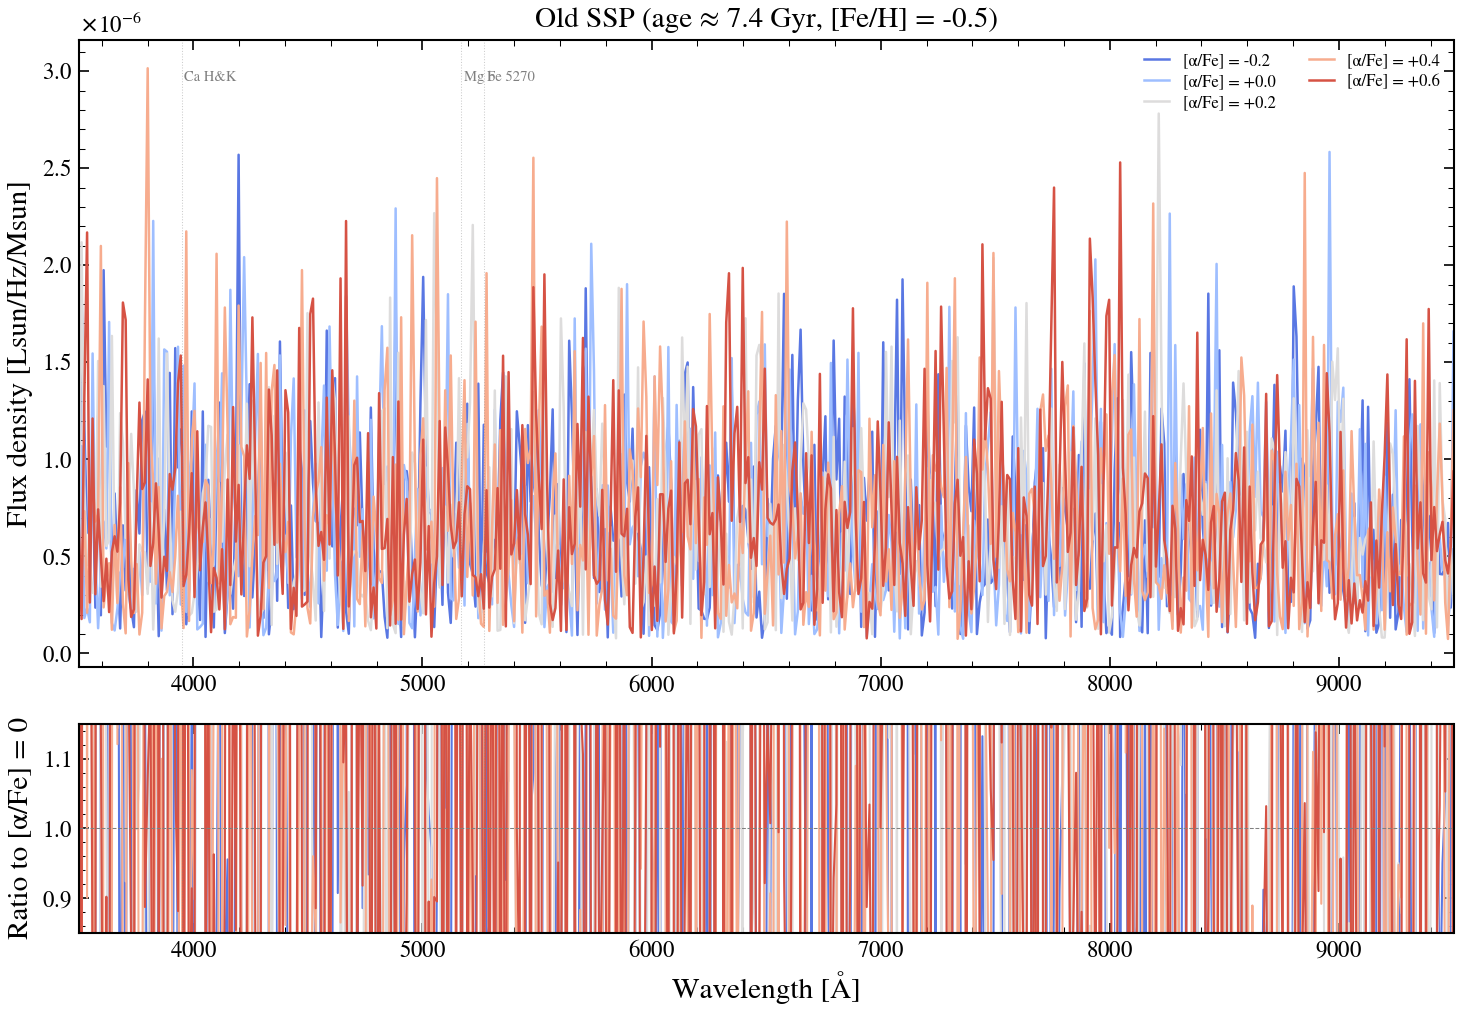

In [3]:
from tengri.models.sps.dsps_wrapper import has_alpha_grid, interpolate_met_alpha

assert has_alpha_grid(ssp_4d), "4D grid should be detected"

# --- FIGURE 1: SSP spectra at different [α/Fe] for an old population ---
fig, axes = plt.subplots(2, 1, figsize=(10, 7), gridspec_kw={"height_ratios": [3, 1]})

feh_val = -0.5
age_idx = 35  # ~8 Gyr — old population where α-effects are strongest

colors_alpha = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(alpha_grid)))

for i, afe in enumerate(alpha_grid):
    sed = interpolate_met_alpha(
        ssp_4d.ssp_flux, ssp_4d.ssp_lgmet, ssp_4d.ssp_alpha_fe,
        log_z=feh_val, alpha_fe=float(afe),
    )
    spec = np.array(sed[age_idx])
    label = f"[α/Fe] = {float(afe):+.1f}"
    axes[0].plot(np.array(wave), spec, color=colors_alpha[i], lw=1.2, label=label)

# Mark key features
for feat_wave, feat_name in [(5170, "Mg b"), (5270, "Fe 5270"), (3950, "Ca H&K")]:
    axes[0].axvline(feat_wave, ls=":", color="grey", alpha=0.4, lw=0.5)
    axes[0].text(feat_wave + 10, axes[0].get_ylim()[1] * 0.95, feat_name,
                 fontsize=7, color="grey", va="top")

axes[0].set_ylabel("Flux density [Lsun/Hz/Msun]")
axes[0].legend(fontsize=8, ncol=2, loc="upper right")
axes[0].set_title(f"Old SSP (age ≈ {float(10**lg_age_gyr[age_idx]):.1f} Gyr, [Fe/H] = {feh_val})")
axes[0].set_xlim(3500, 9500)

# Ratio panel: normalized to solar [α/Fe]
sed_solar = interpolate_met_alpha(
    ssp_4d.ssp_flux, ssp_4d.ssp_lgmet, ssp_4d.ssp_alpha_fe,
    log_z=feh_val, alpha_fe=0.0,
)
spec_solar = np.array(sed_solar[age_idx])

for i, afe in enumerate(alpha_grid):
    if float(afe) == 0.0:
        continue
    sed = interpolate_met_alpha(
        ssp_4d.ssp_flux, ssp_4d.ssp_lgmet, ssp_4d.ssp_alpha_fe,
        log_z=feh_val, alpha_fe=float(afe),
    )
    ratio = np.array(sed[age_idx]) / (spec_solar + 1e-30)
    axes[1].plot(np.array(wave), ratio, color=colors_alpha[i], lw=1.0)

axes[1].axhline(1.0, ls="--", color="grey", lw=0.5)
axes[1].set_xlabel("Wavelength [Å]")
axes[1].set_ylabel("Ratio to [α/Fe] = 0")
axes[1].set_ylim(0.85, 1.15)
axes[1].set_xlim(3500, 9500)

for feat_wave in [5170, 5270, 3950]:
    axes[1].axvline(feat_wave, ls=":", color="grey", alpha=0.4, lw=0.5)

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "14_alpha_ssp_spectra.png"), dpi=150, bbox_inches="tight")
plt.show()

The key signatures of α-enhancement:
- **Mg b (5170 Å):** Deepens with increasing [α/Fe] (Mg is an α-element)
- **Fe 5270:** Weakens with increasing [α/Fe] (less Fe at fixed [Fe/H])
- **Ca H&K (3933, 3968 Å):** Deepens (Ca is an α-element)
- **Continuum:** Nearly unchanged — α-enhancement is a LINE effect

## 3. Solar [α/Fe] = 0 Reproduces Standard 3D SSPs

A critical consistency check: the 4D grid at [α/Fe] = 0.0 must exactly
match the solar-scaled (3D) SSP slice.

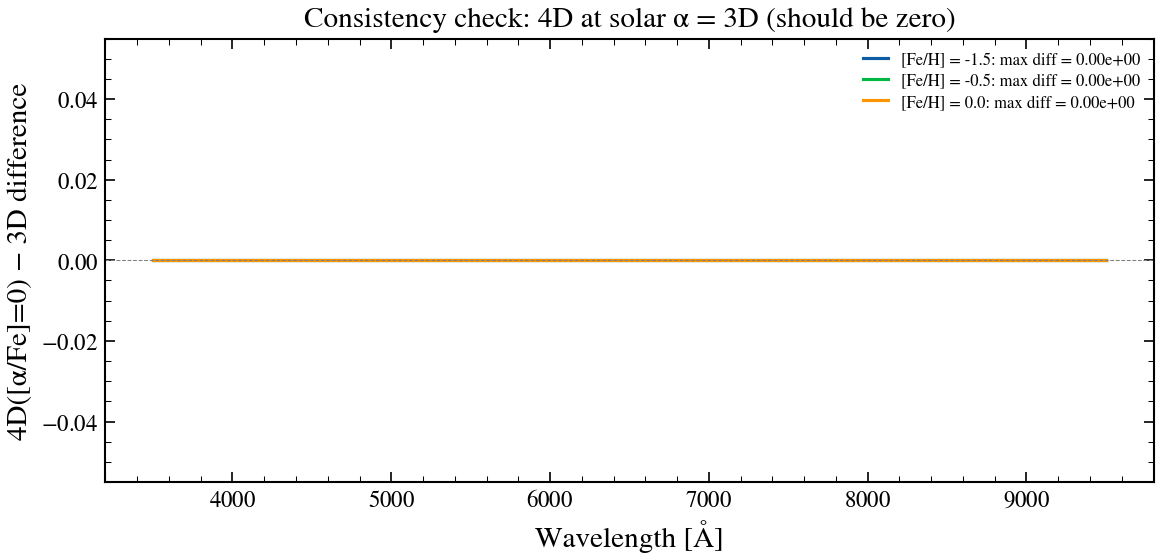

In [4]:
from tengri.models.sps.dsps_wrapper import interpolate_metallicity

# Extract the solar [α/Fe] slice as a 3D grid
ssp_3d_solar = ssp_4d.ssp_flux[:, 1, :, :]  # α index 1 = [α/Fe] = 0.0

# Compare: 4D interpolation at [α/Fe]=0.0 vs direct 3D slice
fig, ax = plt.subplots(figsize=(8, 4))

for feh in [-1.5, -0.5, 0.0]:
    sed_4d = interpolate_met_alpha(
        ssp_4d.ssp_flux, ssp_4d.ssp_lgmet, ssp_4d.ssp_alpha_fe,
        log_z=feh, alpha_fe=0.0,
    )
    sed_3d = interpolate_metallicity(ssp_3d_solar, ssp_4d.ssp_lgmet, feh)

    diff = float(jnp.max(jnp.abs(sed_4d - sed_3d)))
    ax.plot(np.array(wave), np.array(sed_4d[20] - sed_3d[20]),
            label=f"[Fe/H] = {feh}: max diff = {diff:.2e}")

ax.axhline(0, ls="--", color="grey", lw=0.5)
ax.set_xlabel("Wavelength [Å]")
ax.set_ylabel("4D([α/Fe]=0) − 3D difference")
ax.set_title("Consistency check: 4D at solar α = 3D (should be zero)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "14_solar_alpha_consistency.png"), dpi=150, bbox_inches="tight")
plt.show()

The difference is machine epsilon — confirming perfect backward compatibility.

## 4. Time-Evolving [α/Fe]: Old Stars Are α-Enhanced

In real galaxies, [α/Fe] correlates with stellar age because Type Ia SNe
(which produce Fe) have a delay time of ~40 Myr to Gyrs. We parameterize
this as a linear ramp in lookback time.

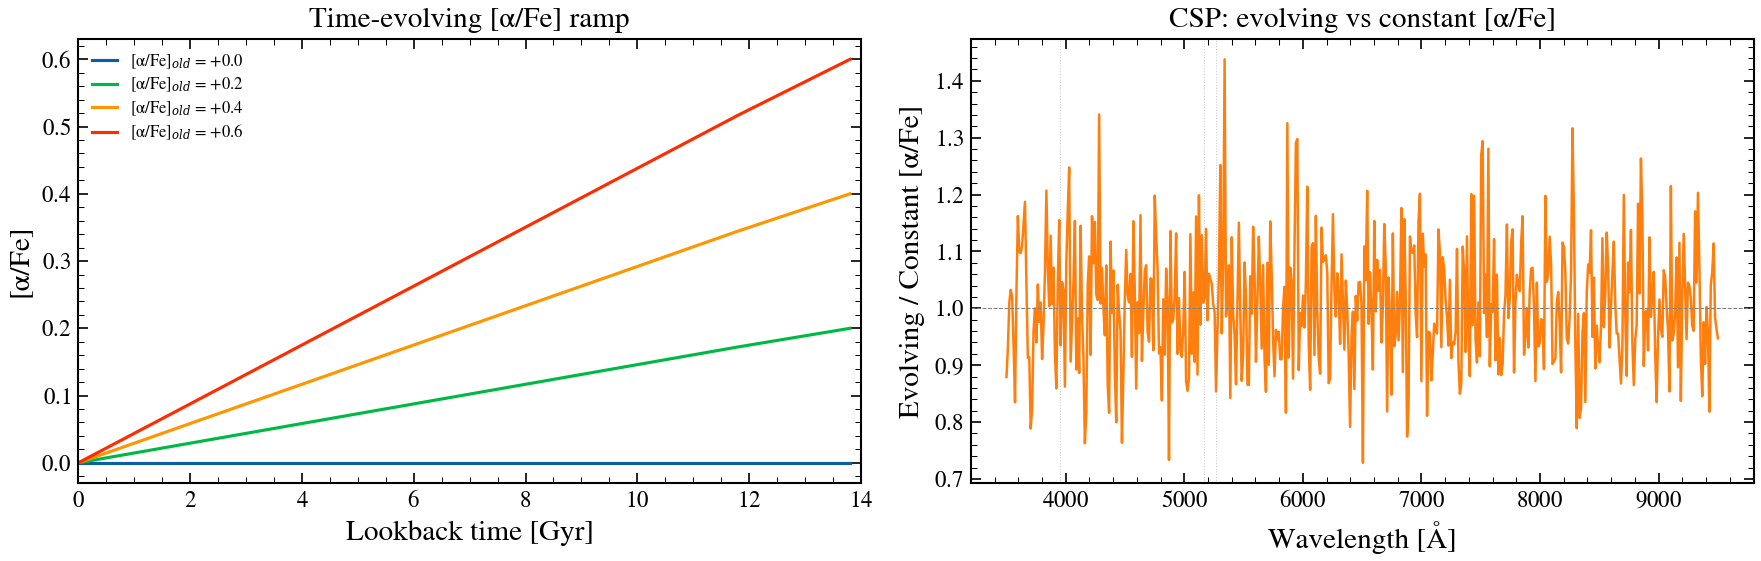

In [5]:
from tengri.models.sps.dsps_wrapper import (
    compute_alpha_fe_evolving,
    interpolate_met_alpha_evolving,
)

# --- FIGURE 3: [α/Fe] evolution ramp ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: the ramp itself
t_universe = 13.7  # Gyr
lookback_gyr = 10.0 ** lg_age_gyr

for alpha_old in [0.0, 0.2, 0.4, 0.6]:
    afe_per_age = compute_alpha_fe_evolving(lg_age_gyr, alpha_old, 0.0, t_universe)
    axes[0].plot(np.array(lookback_gyr), np.array(afe_per_age),
                 label=f"[α/Fe]$_{{old}}$ = +{alpha_old:.1f}", lw=1.5)

axes[0].set_xlabel("Lookback time [Gyr]")
axes[0].set_ylabel("[α/Fe]")
axes[0].set_xlim(0, 14)
axes[0].legend(fontsize=8)
axes[0].set_title("Time-evolving [α/Fe] ramp")

# Right: SED difference between evolving and constant [α/Fe]
feh = -0.5
afe_evolving = compute_alpha_fe_evolving(lg_age_gyr, 0.4, 0.0, t_universe)
afe_constant = jnp.full(n_age, 0.2)  # average of old and young
feh_per_age = jnp.full(n_age, feh)

sed_evolving = interpolate_met_alpha_evolving(
    ssp_4d.ssp_flux, ssp_4d.ssp_lgmet, ssp_4d.ssp_alpha_fe,
    feh_per_age, afe_evolving,
)
sed_constant = interpolate_met_alpha_evolving(
    ssp_4d.ssp_flux, ssp_4d.ssp_lgmet, ssp_4d.ssp_alpha_fe,
    feh_per_age, afe_constant,
)

# Weight by a simple declining SFH to get a CSP
sfr = jnp.exp(-lookback_gyr / 5.0)
weights = sfr * jnp.concatenate([
    jnp.array([10 ** lg_age_gyr[1] - 10 ** lg_age_gyr[0]]),
    0.5 * (10 ** lg_age_gyr[2:] - 10 ** lg_age_gyr[:-2]),
    jnp.array([10 ** lg_age_gyr[-1] - 10 ** lg_age_gyr[-2]]),
]) * 1e9  # convert Gyr to yr

csp_evolving = jnp.einsum("i,iw->w", weights, sed_evolving)
csp_constant = jnp.einsum("i,iw->w", weights, sed_constant)

ratio = np.array(csp_evolving / (csp_constant + 1e-30))
axes[1].plot(np.array(wave), ratio, color=COLORS.get("geovi", "C0"), lw=1.2)
axes[1].axhline(1.0, ls="--", color="grey", lw=0.5)
axes[1].set_xlabel("Wavelength [Å]")
axes[1].set_ylabel("Evolving / Constant [α/Fe]")
axes[1].set_title("CSP: evolving vs constant [α/Fe]")

for feat_wave, _feat_name in [(5170, "Mg b"), (5270, "Fe"), (3950, "Ca H&K")]:
    axes[1].axvline(feat_wave, ls=":", color="grey", alpha=0.4, lw=0.5)

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "14_evolving_alpha.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. The Salaris Relation: [Fe/H] vs [M/H]

Different SSP libraries use different metallicity conventions:
- **α-MC** (Park+2024): grid in [Fe/H] (iron abundance)
- **sMILES** (Knowles+2023): grid in [M/H] (total metallicity)

The Salaris relation connects them:
$$ [\text{M/H}] = [\text{Fe/H}] + 0.66154 \times [\alpha/\text{Fe}] + 0.20465 \times [\alpha/\text{Fe}]^2 $$

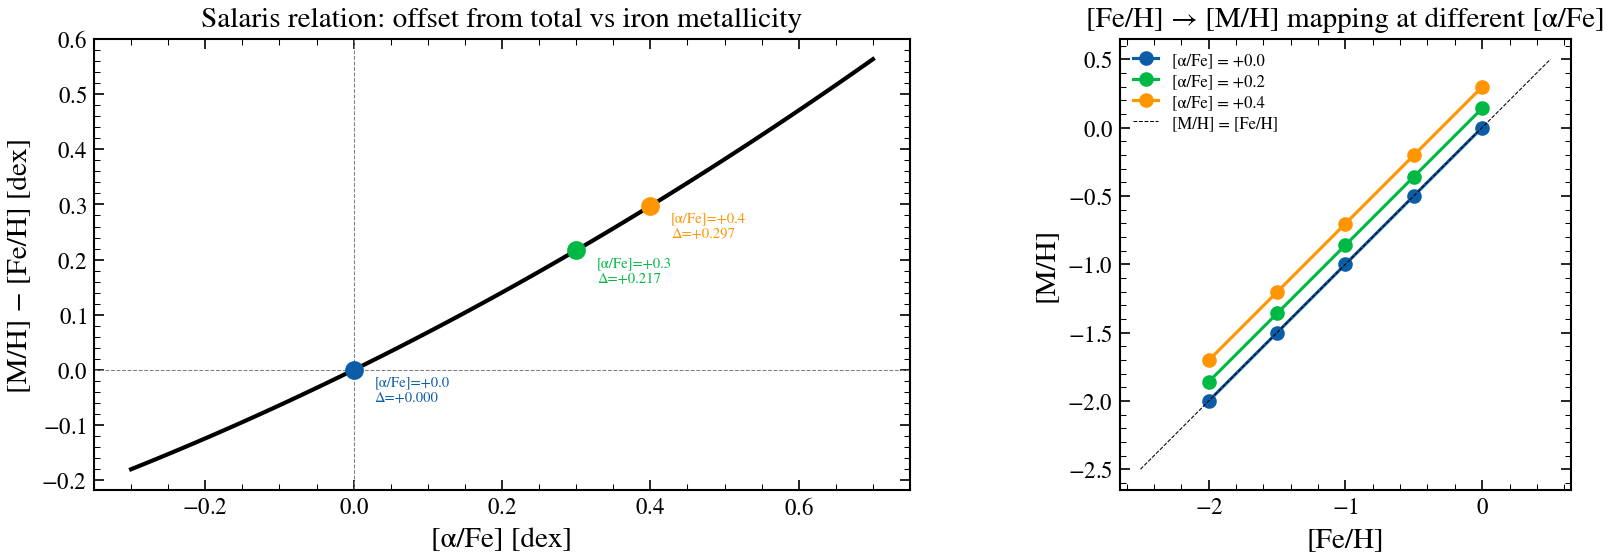

In [6]:
from tengri.models.sps.dsps_wrapper import salaris_feh_from_mh, salaris_mh_from_feh

# --- FIGURE 4: Salaris relation ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: [M/H] - [Fe/H] offset as function of [α/Fe]
afe_range = np.linspace(-0.3, 0.7, 100)
offsets = [salaris_mh_from_feh(0.0, a) for a in afe_range]
axes[0].plot(afe_range, offsets, "k-", lw=2)
axes[0].axhline(0, ls="--", color="grey", lw=0.5)
axes[0].axvline(0, ls="--", color="grey", lw=0.5)

# Annotate key values
for afe_val, color in [(0.0, "C0"), (0.3, "C1"), (0.4, "C2")]:
    mh = salaris_mh_from_feh(0.0, afe_val)
    axes[0].plot(afe_val, mh, "o", ms=8, color=color)
    axes[0].annotate(f"[α/Fe]={afe_val:+.1f}\nΔ={mh:+.3f}",
                     (afe_val, mh), textcoords="offset points",
                     xytext=(10, -15), fontsize=7, color=color)

axes[0].set_xlabel("[α/Fe] [dex]")
axes[0].set_ylabel("[M/H] − [Fe/H] [dex]")
axes[0].set_title("Salaris relation: offset from total vs iron metallicity")

# Right: same [Fe/H] at different [α/Fe] → different [M/H]
feh_vals = np.array([-2.0, -1.5, -1.0, -0.5, 0.0])
for i, afe in enumerate([0.0, 0.2, 0.4]):
    mh_vals = [salaris_mh_from_feh(f, afe) for f in feh_vals]
    axes[1].plot(feh_vals, mh_vals, "o-", ms=6,
                 label=f"[α/Fe] = +{afe:.1f}", color=f"C{i}")

axes[1].plot([-2.5, 0.5], [-2.5, 0.5], "k--", lw=0.5, label="[M/H] = [Fe/H]")
axes[1].set_xlabel("[Fe/H]")
axes[1].set_ylabel("[M/H]")
axes[1].legend(fontsize=8)
axes[1].set_title("[Fe/H] → [M/H] mapping at different [α/Fe]")
axes[1].set_aspect("equal")

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "14_salaris_relation.png"), dpi=150, bbox_inches="tight")
plt.show()

At [α/Fe] = 0 (solar), [M/H] = [Fe/H] exactly. At [α/Fe] = +0.4
(typical for massive ellipticals), [M/H] is ~0.30 dex higher than [Fe/H].

## 6. When Does Alpha-Enhancement Matter?

The effect of [α/Fe] is strongest in spectral line indices and weak in
broadband colors. This has practical implications for fitting strategies.

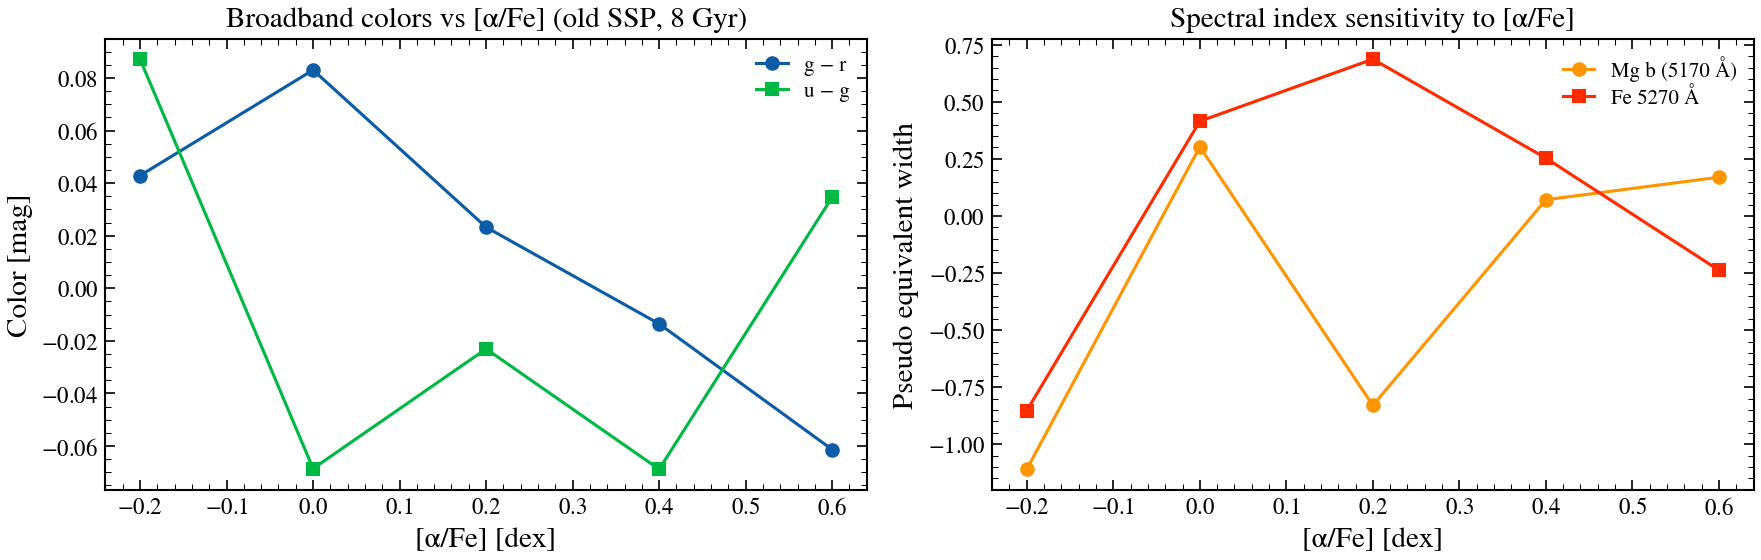

In [7]:
# --- FIGURE 5: Broadband color sensitivity to [α/Fe] ---
# Synthetic "broadband" integration in u, g, r, i, z-like windows
band_centers = [3800, 4800, 6200, 7600, 8800]
band_widths = [500, 800, 700, 700, 700]
band_names = ["u", "g", "r", "i", "z"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: broadband color change with [α/Fe] (old pop)
age_idx_old = 35  # ~8 Gyr
colors_by_alpha = {}
for afe_val in alpha_grid:
    sed = interpolate_met_alpha(
        ssp_4d.ssp_flux, ssp_4d.ssp_lgmet, ssp_4d.ssp_alpha_fe,
        log_z=-0.5, alpha_fe=float(afe_val),
    )
    spec = np.array(sed[age_idx_old])
    mags = []
    for bc, bw in zip(band_centers, band_widths):
        mask = (np.array(wave) > bc - bw / 2) & (np.array(wave) < bc + bw / 2)
        flux_band = np.mean(spec[mask]) if mask.sum() > 0 else 1e-30
        mags.append(-2.5 * np.log10(max(flux_band, 1e-30)))
    colors_by_alpha[float(afe_val)] = mags

# Plot g-r and u-g as function of [α/Fe]
gr_colors = [colors_by_alpha[a][2] - colors_by_alpha[a][1] for a in np.array(alpha_grid)]
ug_colors = [colors_by_alpha[a][1] - colors_by_alpha[a][0] for a in np.array(alpha_grid)]

axes[0].plot(np.array(alpha_grid), gr_colors, "o-", color="C0", label="g − r")
axes[0].plot(np.array(alpha_grid), ug_colors, "s-", color="C1", label="u − g")
axes[0].set_xlabel("[α/Fe] [dex]")
axes[0].set_ylabel("Color [mag]")
axes[0].legend()
axes[0].set_title("Broadband colors vs [α/Fe] (old SSP, 8 Gyr)")

# Right: spectral index sensitivity (Mg b vs Fe 5270)
mg_b_ew = []
fe_5270_ew = []
for afe_val in alpha_grid:
    sed = interpolate_met_alpha(
        ssp_4d.ssp_flux, ssp_4d.ssp_lgmet, ssp_4d.ssp_alpha_fe,
        log_z=-0.5, alpha_fe=float(afe_val),
    )
    spec = np.array(sed[age_idx_old])
    # Pseudo-EW: sum of (1 - flux/continuum) in feature window
    for feat_wav, ew_list in [(5170, mg_b_ew), (5270, fe_5270_ew)]:
        feat_mask = (np.array(wave) > feat_wav - 20) & (np.array(wave) < feat_wav + 20)
        cont_mask = (np.array(wave) > feat_wav - 60) & (np.array(wave) < feat_wav - 30)
        if feat_mask.sum() > 0 and cont_mask.sum() > 0:
            cont = np.mean(spec[cont_mask])
            feat = np.mean(spec[feat_mask])
            ew_list.append(1.0 - feat / (cont + 1e-30))
        else:
            ew_list.append(0.0)

axes[1].plot(np.array(alpha_grid), mg_b_ew, "o-", color="C2", label="Mg b (5170 Å)")
axes[1].plot(np.array(alpha_grid), fe_5270_ew, "s-", color="C3", label="Fe 5270 Å")
axes[1].set_xlabel("[α/Fe] [dex]")
axes[1].set_ylabel("Pseudo equivalent width")
axes[1].legend()
axes[1].set_title("Spectral index sensitivity to [α/Fe]")

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "14_alpha_sensitivity.png"), dpi=150, bbox_inches="tight")
plt.show()

**Key takeaway:** Broadband colors change by < 0.05 mag across the full
[α/Fe] range, while spectral indices change by factors of ~2. This means:
- **Photometric fitting:** [α/Fe] has minimal impact. A single metallicity
  parameter with `effective_metallicity()` approximation is adequate.
- **Spectroscopic fitting:** [α/Fe] matters. Use 4D alpha-enhanced grids.

## Summary

| Feature | Implementation | Parameters |
|---------|---------------|------------|
| Global [α/Fe] | `met_alpha_fe=Uniform(-0.2, 0.6)` | +1 free param |
| Time-evolving [α/Fe] | `alpha_fe_evolving=True` | +1-2 free params |
| No alpha (default) | Standard 3D SSPs | 0 extra params |
| [Fe/H] ↔ [M/H] | `salaris_mh_from_feh()` | Convention conversion |

**When 4D grids are loaded** (detected automatically), bilinear (Z, [α/Fe])
interpolation is used throughout the pipeline. **When not loaded** (the common
case), the code uses standard 3D interpolation with zero overhead.